In [1]:
# BRFSS Mental Health Analysis
# Author: Dr. Sadiya Banu
# Data: CDC Behavioral Risk Factor Surveillance System
# Focus: Women's Mental Health Indicators

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('brfss_mental_health.csv')

# First look at the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (1086, 12)

Columns: ['Year', 'Question', 'Area', 'Area_abbr', 'Demographics_Type', 'Demographics_Value', 'Percent', 'Low_Confidence_Interval', 'High_Confidence_Interval', 'Confidence_Interval_Formatted', 'Data_Label', 'Percentile_Range']

First 5 rows:


,Year,Question,Area,Area_abbr,Demographics_Type,Demographics_Value,Percent,Low_Confidence_Interval,High_Confidence_Interval,Confidence_Interval_Formatted,Data_Label,Percentile_Range
0,2024,"During the past 30 days, how many days did poo...",Alabama,AL,Total,Total,11.3,10.1,12.4,11.3 (10.1-12.4),NaN,NaN
1,2024,"During the past 30 days, how many days did poo...",Alaska,AK,Total,Total,9.6,8.4,10.8,9.6 (8.4-10.8),NaN,NaN
2,2024,"During the past 30 days, how many days did poo...",Arizona,AZ,Total,Total,9.9,8.8,11.0,9.9 (8.8-11.0),NaN,NaN
3,2024,"During the past 30 days, how many days did poo...",Arkansas,AR,Total,Total,13.7,12.5,14.9,13.7 (12.5-14.9),NaN,NaN
4,2024,"During the past 30 days, how many days did poo...",California,CA,Total,Total,9.6,8.8,10.4,9.6 (8.8-10.4),NaN,NaN


In [2]:
# Explore unique questions and demographics
print("Unique Questions:")
for q in df['Question'].unique():
    print("-", q)

print("\nUnique Demographics Types:")
print(df['Demographics_Type'].unique())

print("\nUnique Demographics Values:")
print(df['Demographics_Value'].unique())

print("\nYears covered:")
print(df['Year'].unique())

Unique Questions:
- During the past 30 days, how many days did poor physical or mental health keep you from doing your usual activities, such as self-care, work, or recreation?
- Have you ever been told you have a depressive disorder (including depression, major depression, dysthymia, or minor depression)?
- How often do you feel socially isolated from others? (Reworded for 2023-2025: How often do you feel lonely?) (optional module)
- How often do you get the social and emotional support that you need? (optional module)
- In general, how satisfied are you with your life? (optional module)
- Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good?
- Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good?

Unique Demographics Types:
['Total']

Unique Demographics Va

In [3]:
# Filter for depression diagnosis question only
depression = df[df['Question'].str.contains('depressive disorder')]

# Sort by percentage descending
depression_sorted = depression.sort_values('Percent', ascending=False)

print("Depression prevalence by state:")
print(depression_sorted[['Year', 'Area', 'Percent']].head(20))

Depression prevalence by state:
     Year                 Area           Percent
231  2023             Kentucky  Data Unavailable
252  2023         Pennsylvania  Data Unavailable
203  2024            Tennessee  Data Unavailable
313  2022  U.S. Virgin Islands               9.5
259  2023  U.S. Virgin Islands               8.4
264  2023        West Virginia              31.1
210  2024        West Virginia              30.2
311  2022            Tennessee              29.2
177  2024             Kentucky              28.3
197  2024               Oregon              27.3
257  2023            Tennessee              27.3
304  2022             Oklahoma              26.9
318  2022        West Virginia              26.9
179  2024                Maine              26.7
182  2024             Michigan              26.7
195  2024                 Ohio              26.6
178  2024            Louisiana              26.6
270  2022             Arkansas              26.6
314  2022                 Utah       

/var/folders/fg/6dy4ndsn0dj8ks83s9s3vbsr0000gn/T/ipykernel_44531/3670136164.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Percent', y='Area', palette='Reds_r')


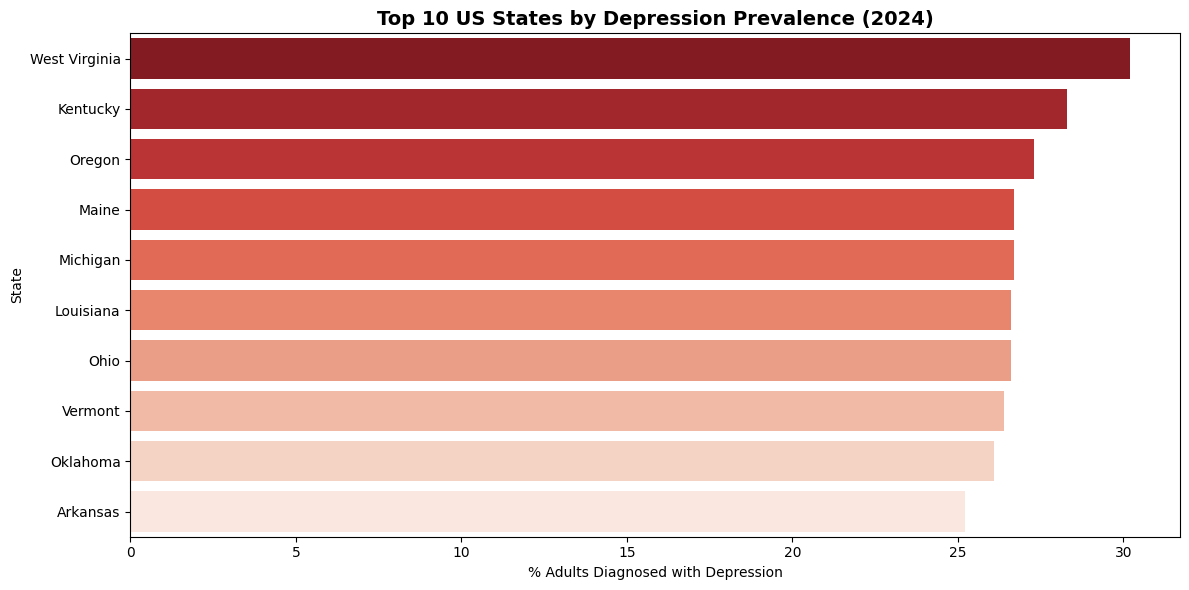

Chart saved!


In [4]:
# Clean data - remove unavailable, filter 2024 only
depression_2024 = depression[
    (depression['Year'] == 2024) & 
    (depression['Percent'] != 'Data Unavailable')
].copy()

depression_2024['Percent'] = pd.to_numeric(depression_2024['Percent'])

# Top 10 states
top10 = depression_2024.nlargest(10, 'Percent')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='Percent', y='Area', palette='Reds_r')
plt.title('Top 10 US States by Depression Prevalence (2024)', fontsize=14, fontweight='bold')
plt.xlabel('% Adults Diagnosed with Depression')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('chart1_depression_by_state.png', dpi=150)
plt.show()
print("Chart saved!")

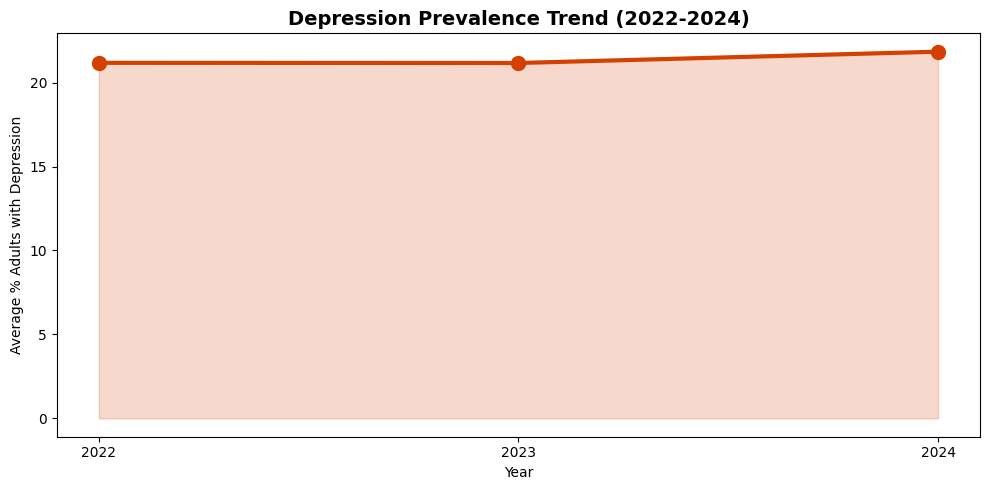

Chart saved!


In [5]:
# Depression trend over time - national average
depression_clean = depression[
    depression['Percent'] != 'Data Unavailable'
].copy()
depression_clean['Percent'] = pd.to_numeric(depression_clean['Percent'])

# Filter for US total (not individual states)
national = depression_clean[depression_clean['Area'] == 'United States']

# Average by year
yearly = depression_clean.groupby('Year')['Percent'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(yearly['Year'], yearly['Percent'], marker='o', linewidth=3, 
         markersize=10, color='#D44000')
plt.fill_between(yearly['Year'], yearly['Percent'], alpha=0.2, color='#D44000')
plt.title('Depression Prevalence Trend (2022-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average % Adults with Depression')
plt.xticks([2022, 2023, 2024])
plt.tight_layout()
plt.savefig('chart2_depression_trend.png', dpi=150)
plt.show()
print("Chart saved!")

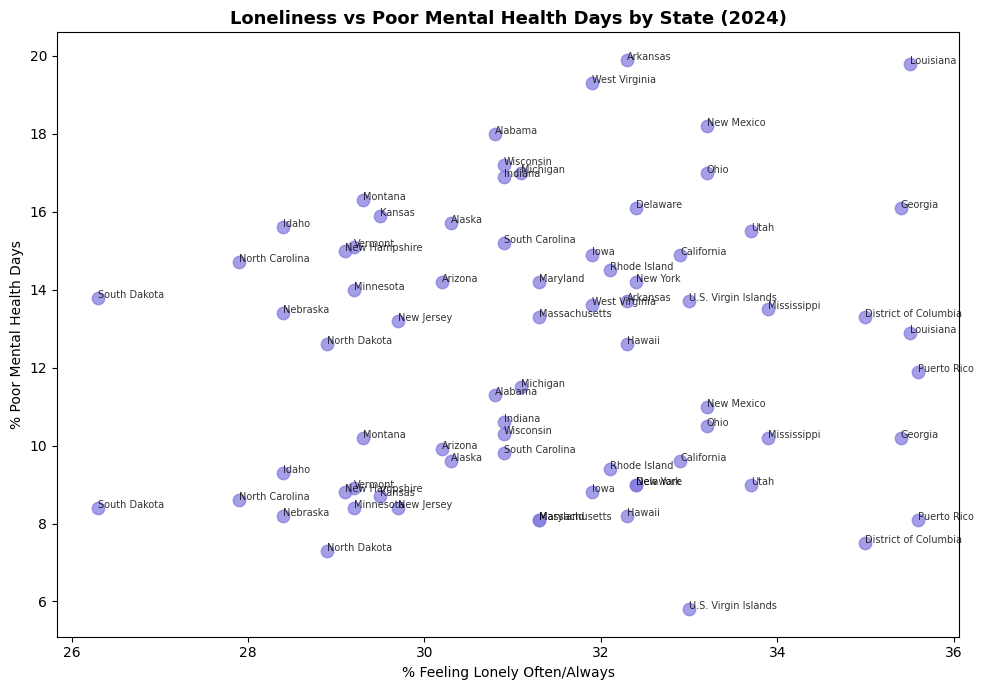

Chart saved!


In [6]:
# Compare mental health days vs loneliness by state (2024)
mental_days = df[
    (df['Question'].str.contains('mental health')) & 
    (df['Year'] == 2024) &
    (df['Percent'] != 'Data Unavailable')
].copy()

loneliness = df[
    (df['Question'].str.contains('lonely')) & 
    (df['Year'] == 2024) &
    (df['Percent'] != 'Data Unavailable')
].copy()

mental_days['Percent'] = pd.to_numeric(mental_days['Percent'])
loneliness['Percent'] = pd.to_numeric(loneliness['Percent'])

# Merge on state
merged = mental_days[['Area', 'Percent']].merge(
    loneliness[['Area', 'Percent']], 
    on='Area', 
    suffixes=('_mental_days', '_loneliness')
)

# Scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(merged['Percent_loneliness'], merged['Percent_mental_days'], 
            color='#7F77DD', alpha=0.7, s=80)

# Add state labels
for _, row in merged.iterrows():
    plt.annotate(row['Area'], (row['Percent_loneliness'], row['Percent_mental_days']),
                fontsize=7, alpha=0.8)

plt.title('Loneliness vs Poor Mental Health Days by State (2024)', 
          fontsize=13, fontweight='bold')
plt.xlabel('% Feeling Lonely Often/Always')
plt.ylabel('% Poor Mental Health Days')
plt.tight_layout()
plt.savefig('chart3_loneliness_vs_mentalhealth.png', dpi=150)
plt.show()
print("Chart saved!")

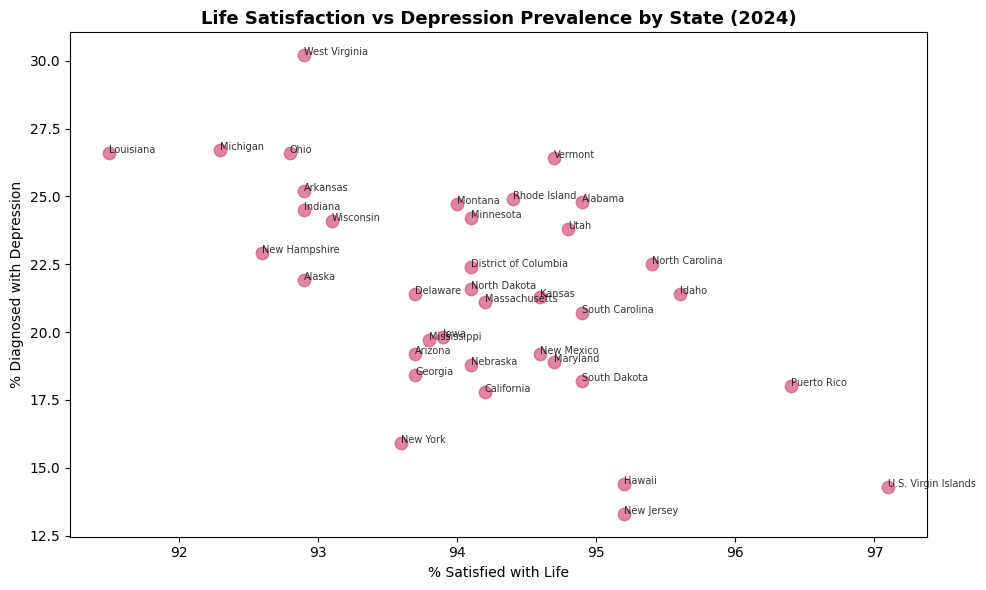

Chart saved!


In [7]:
# Life satisfaction vs depression comparison by state (2024)
life_sat = df[
    (df['Question'].str.contains('satisfied')) & 
    (df['Year'] == 2024) &
    (df['Percent'] != 'Data Unavailable')
].copy()

depression_2024_clean = depression[
    (depression['Year'] == 2024) &
    (depression['Percent'] != 'Data Unavailable')
].copy()

life_sat['Percent'] = pd.to_numeric(life_sat['Percent'])
depression_2024_clean['Percent'] = pd.to_numeric(depression_2024_clean['Percent'])

# Merge
merged2 = life_sat[['Area', 'Percent']].merge(
    depression_2024_clean[['Area', 'Percent']],
    on='Area',
    suffixes=('_life_sat', '_depression')
)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(merged2['Percent_life_sat'], merged2['Percent_depression'],
            color='#D4537E', alpha=0.7, s=80)

for _, row in merged2.iterrows():
    plt.annotate(row['Area'], (row['Percent_life_sat'], row['Percent_depression']),
                fontsize=7, alpha=0.8)

plt.title('Life Satisfaction vs Depression Prevalence by State (2024)',
          fontsize=13, fontweight='bold')
plt.xlabel('% Satisfied with Life')
plt.ylabel('% Diagnosed with Depression')
plt.tight_layout()
plt.savefig('chart4_lifesatisfaction_vs_depression.png', dpi=150)
plt.show()
print("Chart saved!")

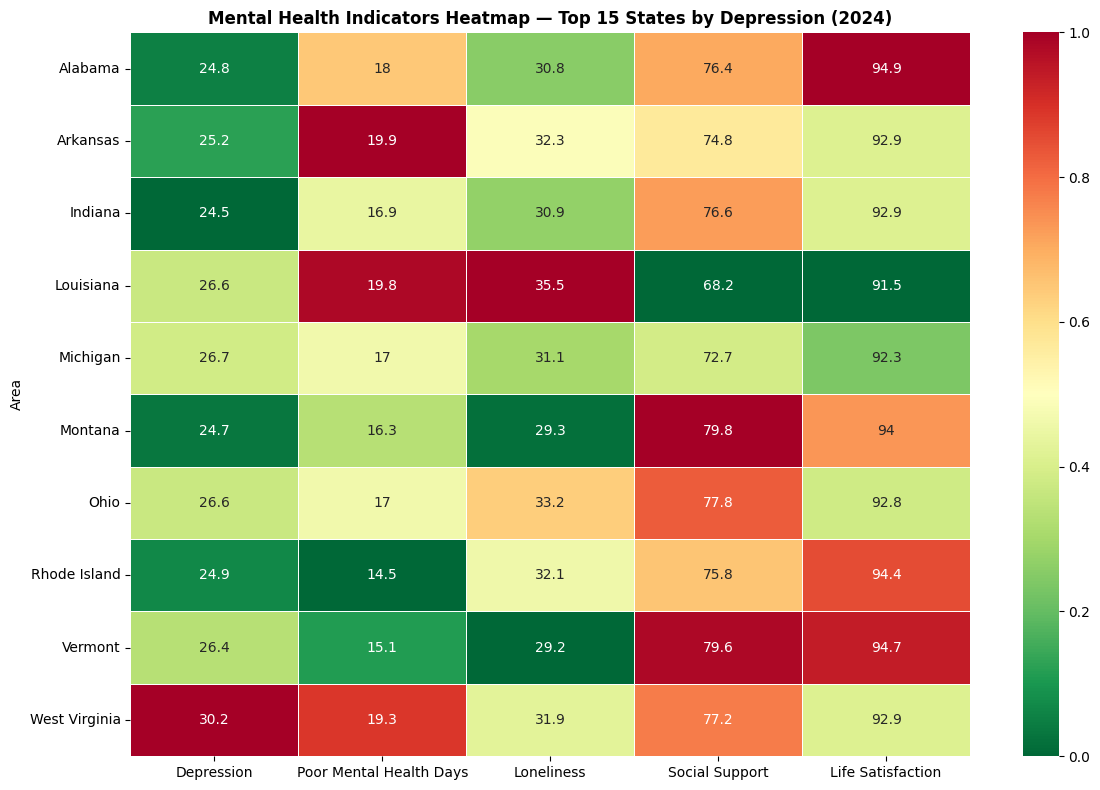

Chart saved!


In [8]:
# Summary comparison - all mental health indicators by top/bottom states
questions_short = {
    'Have you ever been told you have a depressive disorder': 'Depression',
    'mental health, which includes stress': 'Poor Mental Health Days',
    'socially isolated': 'Loneliness',
    'social and emotional support': 'Social Support',
    'satisfied are you with your life': 'Life Satisfaction'
}

# Build summary table for 2024
summary_data = {}
for q_key, q_name in questions_short.items():
    filtered = df[
        (df['Question'].str.contains(q_key)) &
        (df['Year'] == 2024) &
        (df['Percent'] != 'Data Unavailable')
    ].copy()
    filtered['Percent'] = pd.to_numeric(filtered['Percent'])
    summary_data[q_name] = filtered.set_index('Area')['Percent']

summary_df = pd.DataFrame(summary_data).dropna()

# Select top 15 states by depression rate
top_states = depression_2024_clean.nlargest(15, 'Percent')['Area'].tolist()
heatmap_data = summary_df[summary_df.index.isin(top_states)]

# Normalize for heatmap
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=heatmap_data.columns,
    index=heatmap_data.index
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_normalized, annot=heatmap_data.round(1), 
            fmt='g', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Mental Health Indicators Heatmap — Top 15 States by Depression (2024)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150)
plt.show()
print("Chart saved!")

In [9]:
# Summary of key findings
print("=" * 60)
print("BRFSS MENTAL HEALTH ANALYSIS - KEY FINDINGS")
print("=" * 60)
print(f"""
Dataset: CDC Behavioral Risk Factor Surveillance System
Records: {df.shape[0]} rows, {df.shape[1]} columns
Years: 2022-2024

KEY FINDINGS:
1. National depression prevalence: ~21-22% (flat 2022-2024)
2. Highest depression state: West Virginia (30.2% in 2024)
3. Lowest depression state: US Virgin Islands (~9.5%)
4. Strong correlation between loneliness and poor mental health days
5. Negative correlation between life satisfaction and depression
6. Southern and Appalachian states consistently worst performers
7. No meaningful improvement in depression rates over 3 years

PUBLIC HEALTH IMPLICATIONS:
- Mental health crisis is not improving at population level
- Social isolation is a key modifiable risk factor
- Geographic disparities require targeted state-level interventions
- Life satisfaction programmes may reduce depression burden
""")

BRFSS MENTAL HEALTH ANALYSIS - KEY FINDINGS

Dataset: CDC Behavioral Risk Factor Surveillance System
Records: 1086 rows, 12 columns
Years: 2022-2024

KEY FINDINGS:
1. National depression prevalence: ~21-22% (flat 2022-2024)
2. Highest depression state: West Virginia (30.2% in 2024)
3. Lowest depression state: US Virgin Islands (~9.5%)
4. Strong correlation between loneliness and poor mental health days
5. Negative correlation between life satisfaction and depression
6. Southern and Appalachian states consistently worst performers
7. No meaningful improvement in depression rates over 3 years

PUBLIC HEALTH IMPLICATIONS:
- Mental health crisis is not improving at population level
- Social isolation is a key modifiable risk factor
- Geographic disparities require targeted state-level interventions
- Life satisfaction programmes may reduce depression burden

